In [6]:
import pandas as pd
import numpy as np



In [7]:

df = pd.read_csv("../data/raw/upi_transactions_2024.csv")

In [8]:
print(df.head())

  transaction id            timestamp transaction type merchant_category  \
0  TXN0000000001  2024-10-08 15:17:28              P2P     Entertainment   
1  TXN0000000002  2024-04-11 06:56:00              P2M           Grocery   
2  TXN0000000003  2024-04-02 13:27:18              P2P           Grocery   
3  TXN0000000004  2024-01-07 10:09:17              P2P              Fuel   
4  TXN0000000005  2024-01-23 19:04:23              P2P          Shopping   

   amount (INR) transaction_status sender_age_group receiver_age_group  \
0           868            SUCCESS            26-35              18-25   
1          1011            SUCCESS            26-35              26-35   
2           477            SUCCESS            26-35              36-45   
3          2784            SUCCESS            26-35              26-35   
4           990            SUCCESS            26-35              18-25   

    sender_state sender_bank receiver_bank device_type network_type  \
0          Delhi        Axi

In [31]:
df.columns

Index(['transaction_id', 'timestamp', 'transaction_type', 'merchant_category',
       'amount_(inr)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='str')

In [10]:
df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   transaction id      250000 non-null  str  
 1   timestamp           250000 non-null  str  
 2   transaction type    250000 non-null  str  
 3   merchant_category   250000 non-null  str  
 4   amount (INR)        250000 non-null  int64
 5   transaction_status  250000 non-null  str  
 6   sender_age_group    250000 non-null  str  
 7   receiver_age_group  250000 non-null  str  
 8   sender_state        250000 non-null  str  
 9   sender_bank         250000 non-null  str  
 10  receiver_bank       250000 non-null  str  
 11  device_type         250000 non-null  str  
 12  network_type        250000 non-null  str  
 13  fraud_flag          250000 non-null  int64
 14  hour_of_day         250000 non-null  int64
 15  day_of_week         250000 non-null  str  
 16  is_weekend          250000 non-

In [12]:
len(df)

250000

In [13]:
len(df)

250000

In [14]:
df['amount (INR)'].mean()

np.float64(1311.756036)

In [15]:
df['amount (INR)'].max()

np.int64(42099)

In [16]:
df['amount (INR)'].min()

np.int64(10)

In [18]:
import matplotlib.pyplot as plt

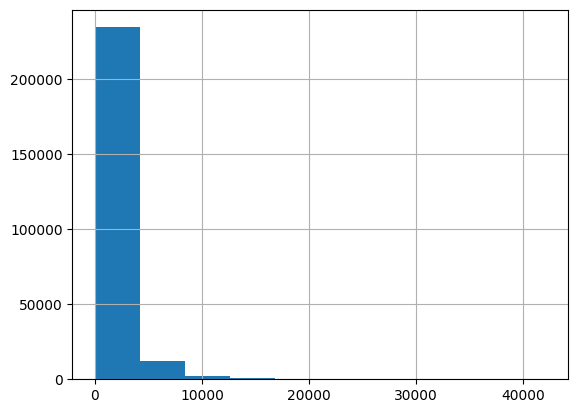

In [19]:
df['amount (INR)'].hist()

plt.show()

In [20]:
df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

In [21]:
df.drop_duplicates(inplace=True)

In [9]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

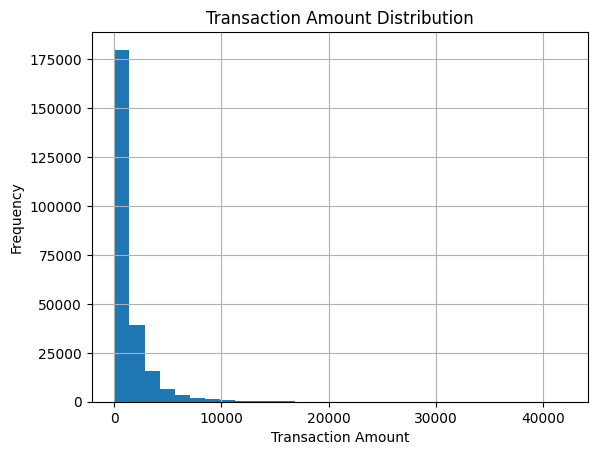

In [28]:
df['amount_(inr)'].hist(bins=30)

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")

plt.show()

In [32]:
df['merchant_category'].value_counts()

merchant_category
Grocery          49966
Food             37464
Shopping         29872
Fuel             25063
Other            24828
Utilities        22338
Transport        20105
Entertainment    20103
Healthcare       12663
Education         7598
Name: count, dtype: int64

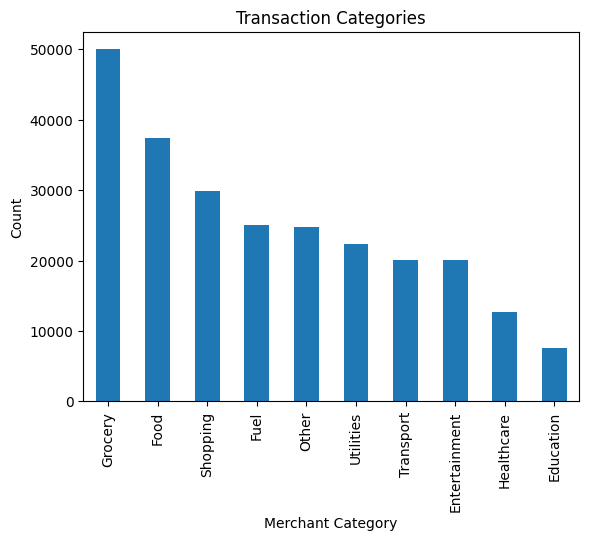

In [34]:
df['merchant_category'].value_counts().plot(kind='bar')

plt.title("Transaction Categories")
plt.xlabel("Merchant Category")
plt.ylabel("Count")

plt.show()

In [39]:
df['merchant_category'].value_counts().head(10)

merchant_category
Grocery          49966
Food             37464
Shopping         29872
Fuel             25063
Other            24828
Utilities        22338
Transport        20105
Entertainment    20103
Healthcare       12663
Education         7598
Name: count, dtype: int64

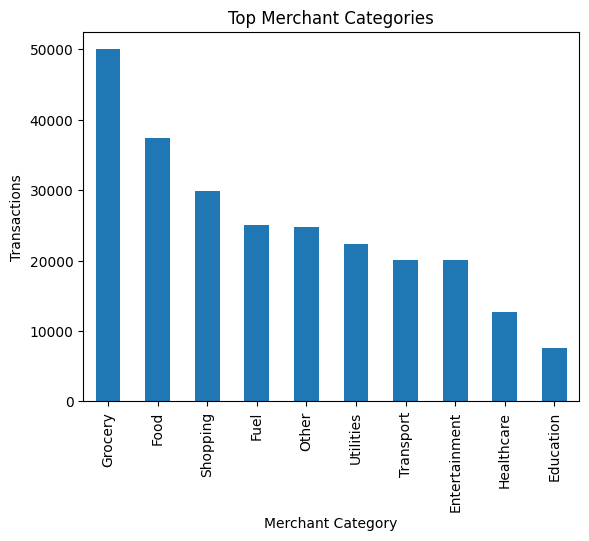

In [41]:
df['merchant_category'].value_counts().head(10).plot(kind='bar')

plt.title("Top Merchant Categories")
plt.xlabel("Merchant Category")
plt.ylabel("Transactions")

plt.show()

In [50]:
print(df.columns)

Index(['transaction_id', 'timestamp', 'transaction_type', 'merchant_category',
       'amount_(inr)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='str')


In [51]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [54]:
df['month'] = df['timestamp'].dt.month

In [55]:
monthly_spending = df.groupby('month')['amount_(inr)'].sum()

print(monthly_spending)

month
1     27456691
2     25826330
3     27508202
4     26988791
5     28024857
6     27032118
7     28079905
8     27845907
9     27105761
10    27866829
11    26892531
12    27311087
Name: amount_(inr), dtype: int64


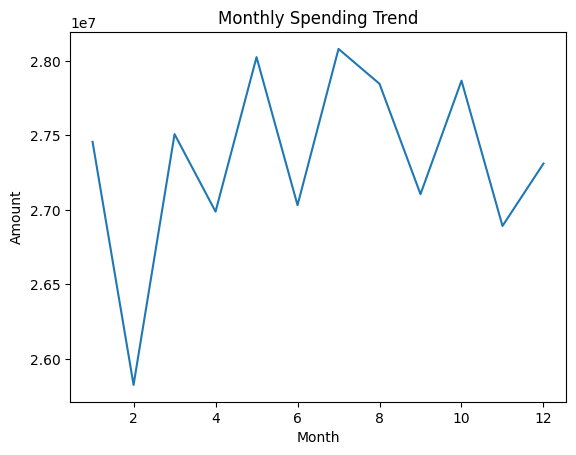

In [56]:
monthly_spending.plot(kind='line')

plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.show()

In [58]:
df['day_name'] = df['timestamp'].dt.day_name()

In [59]:
df['day_name'].value_counts()

day_name
Monday       36495
Sunday       36003
Wednesday    35700
Tuesday      35540
Friday       35496
Thursday     35432
Saturday     35334
Name: count, dtype: int64

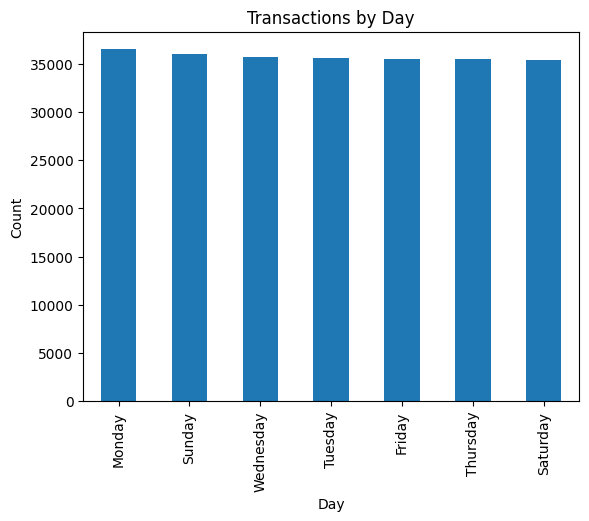

In [60]:
df['day_name'].value_counts().plot(kind='bar')

plt.title("Transactions by Day")
plt.xlabel("Day")
plt.ylabel("Count")

plt.show()

In [62]:
df['fraud_flag'].value_counts()

fraud_flag
0    249520
1       480
Name: count, dtype: int64

In [63]:
(df['fraud_flag'].sum() / len(df)) * 100

np.float64(0.192)

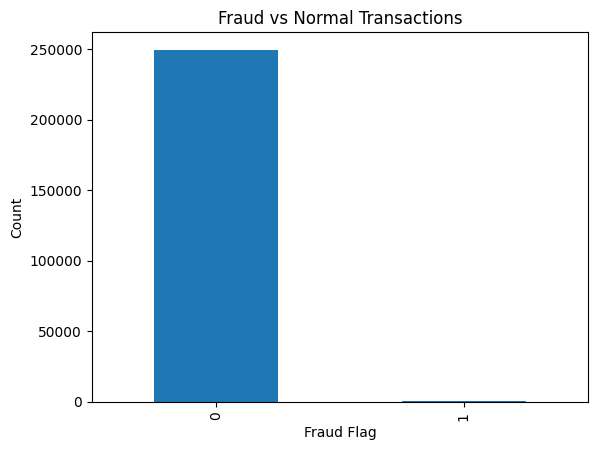

In [64]:
import matplotlib.pyplot as plt

df['fraud_flag'].value_counts().plot(kind='bar')

plt.title("Fraud vs Normal Transactions")
plt.xlabel("Fraud Flag")
plt.ylabel("Count")

plt.show()

In [65]:
fraud_data = df[df['fraud_flag'] == 1]

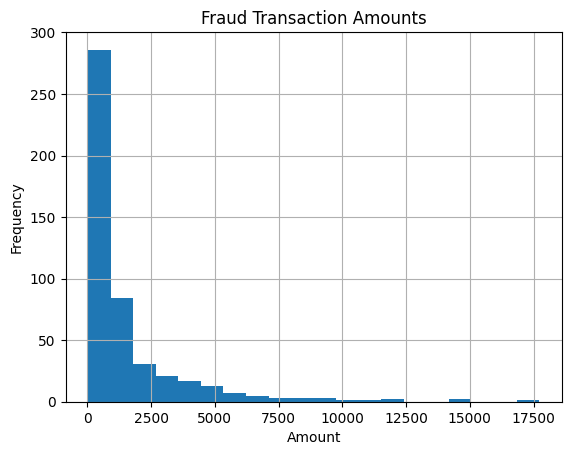

In [66]:
fraud_data['amount_(inr)'].hist(bins=20)

plt.title("Fraud Transaction Amounts")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

In [67]:
fraud_data['merchant_category'].value_counts()

merchant_category
Grocery          94
Food             73
Shopping         62
Other            50
Fuel             48
Transport        43
Entertainment    40
Utilities        33
Healthcare       21
Education        16
Name: count, dtype: int64

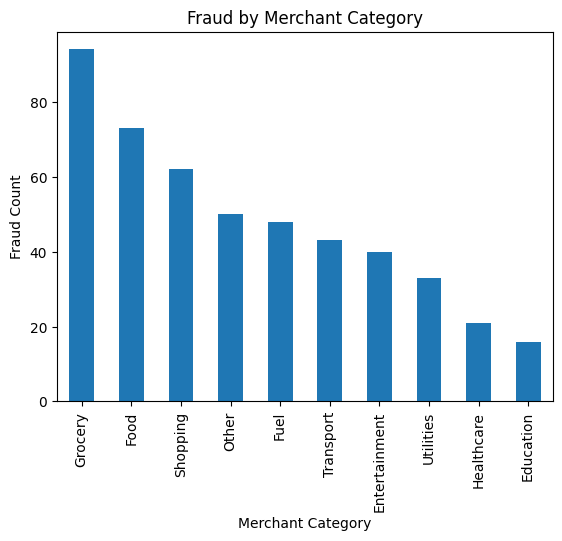

In [68]:
fraud_data['merchant_category'].value_counts().plot(kind='bar')

plt.title("Fraud by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Count")

plt.show()

In [69]:
fraud_data['hour_of_day'].value_counts().sort_index()

hour_of_day
0      8
1      6
2      3
3      4
4      1
5      1
6      5
7     13
8     18
9     20
10    20
11    27
12    30
13    25
14    21
15    32
16    31
17    37
18    31
19    43
20    37
21    35
22    23
23     9
Name: count, dtype: int64

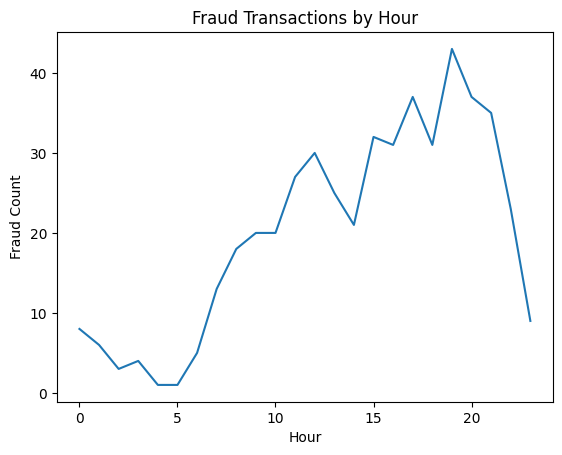

In [70]:
fraud_data['hour_of_day'].value_counts().sort_index().plot(kind='line')

plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Count")

plt.show()

In [71]:
fraud_data['is_weekend'].value_counts()

is_weekend
0    337
1    143
Name: count, dtype: int64

In [10]:
X = df[['amount_(inr)', 'hour_of_day', 'is_weekend']]
y = df['fraud_flag']

In [2]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
model = RandomForestClassifier()

In [15]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
y_pred = model.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score

In [18]:
accuracy_score(y_test, y_pred)

0.9978

In [19]:
from sklearn.metrics import classification_report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     49912
           1       0.00      0.00      0.00        88

    accuracy                           1.00     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       1.00      1.00      1.00     50000



In [29]:
sample = pd.DataFrame({
    'amount_(inr)': [5000],
    'hour_of_day': [23],
    'is_weekend': [1]
})

In [30]:
model.predict(sample)

array([0])

In [7]:
import joblib

joblib.dump(model, "../models/fraud_model.pkl")

['../models/fraud_model.pkl']

In [9]:
print(model)

RandomForestClassifier()


In [10]:
import joblib

joblib.dump(model, "../models/fraud_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [12]:
import os

print(os.listdir("../models"))

['fraud_model.pkl']
